In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/Users/zeeshanhussain/Desktop/pythonproject/nykaa.csv")

df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 55555
Columns: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), i

In [4]:
df.isnull().sum().sort_values(ascending=False)

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [5]:
df.isnull().sum().sort_values(ascending=False)

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Duration,55555.0,17.446044,7.520438,5.00,11.000,17.00,24.000,30.00
Impressions,55555.0,55087.885357,25930.001514,10001.00,32680.000,55182.00,77514.500,100000.00
Clicks,55555.0,4688.070507,3178.686285,202.00,2110.000,3907.00,6688.000,14868.00
Leads,55555.0,1877.271119,1435.636117,56.00,779.000,1481.00,2605.000,8876.00
Conversions,55555.0,1032.866925,862.496788,19.00,400.000,779.00,1414.000,6686.00
Revenue,55555.0,515819.715273,490012.112118,6183.00,177706.000,360436.00,687422.500,4579910.00
Acquisition_Cost,55555.0,377.347068,541.084524,9.08,105.435,207.51,428.580,15473.16
ROI,55555.0,2.713807,4.493380,-0.97,0.040,1.24,3.630,74.42
Engagement_Score,55555.0,13.784169,6.353125,2.60,8.360,13.60,18.855,30.91


In [8]:
df["CTR"] = np.where(
    df["Impressions"] > 0,
    (df["Clicks"] / df["Impressions"]) * 100,
    0
)

df["Conversion_Rate"] = np.where(
    df["Clicks"] > 0,
    (df["Conversions"] / df["Clicks"]) * 100,
    0
)

df["Cost_Per_Click"] = np.where(
    df["Clicks"] > 0,
    df["Acquisition_Cost"] / df["Clicks"],
    0
)

df["Cost_Per_Lead"] = np.where(
    df["Leads"] > 0,
    df["Acquisition_Cost"] / df["Leads"],
    0
)

df["Cost_Per_Acquisition"] = np.where(
    df["Conversions"] > 0,
    df["Acquisition_Cost"] / df["Conversions"],
    0
)

df["ROAS"] = np.where(
    df["Acquisition_Cost"] > 0,
    df["Revenue"] / df["Acquisition_Cost"],
    0
)

In [9]:
df[[
    "CTR",
    "Conversion_Rate",
    "Cost_Per_Click",
    "Cost_Per_Lead",
    "Cost_Per_Acquisition",
    "ROAS"
]].describe()

,CTR,Conversion_Rate,Cost_Per_Click,Cost_Per_Lead,Cost_Per_Acquisition,ROAS
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000
mean,8.508690,21.971554,0.322856,0.985729,2.106050,6502.705876
std,3.761975,8.772756,1.238342,4.258541,10.408489,14478.387978
min,1.997725,5.961252,0.000621,0.001043,0.001358,0.717985
25%,5.259177,15.263524,0.016674,0.041947,0.076242,442.589208
50%,8.508136,20.474893,0.052268,0.137949,0.264589,1769.869914
75%,11.797958,27.784568,0.188247,0.517627,1.033365,6201.253092
max,14.999354,47.742624,59.512154,253.658361,814.376842,504395.374449


In [11]:
df[[
    "CTR",
    "Conversion_Rate",
    "Cost_Per_Click",
    "Cost_Per_Lead",
    "Cost_Per_Acquisition",
    "ROAS"
]].describe().round(2)

,CTR,Conversion_Rate,Cost_Per_Click,Cost_Per_Lead,Cost_Per_Acquisition,ROAS
count,55555.00,55555.00,55555.00,55555.00,55555.00,55555.00
mean,8.51,21.97,0.32,0.99,2.11,6502.71
std,3.76,8.77,1.24,4.26,10.41,14478.39
min,2.00,5.96,0.00,0.00,0.00,0.72
25%,5.26,15.26,0.02,0.04,0.08,442.59
50%,8.51,20.47,0.05,0.14,0.26,1769.87
75%,11.80,27.78,0.19,0.52,1.03,6201.25
max,15.00,47.74,59.51,253.66,814.38,504395.37


In [12]:
print("Total Revenue:", df["Revenue"].sum())

print("Total Cost:", df["Acquisition_Cost"].sum())

print("Total Impressions:", df["Impressions"].sum())

print("Total Clicks:", df["Clicks"].sum())

print("Total Leads:", df["Leads"].sum())

print("Total Conversions:", df["Conversions"].sum())

print("Average ROI:", round(df["ROI"].mean(),2))

print("Average ROAS:", round(df["ROAS"].mean(),2))

Total Revenue: 28656364282
Total Cost: 20963516.36
Total Impressions: 3060407471
Total Clicks: 260445757
Total Leads: 104291797
Total Conversions: 57380922
Average ROI: 2.71
Average ROAS: 6502.71


In [13]:
campaign_rev = df.groupby(
    "Campaign_Type"
)["Revenue"].sum().sort_values(
    ascending=False
)

campaign_rev

Campaign_Type
Influencer      5769064044
Social Media    5751837620
Paid Ads        5751468983
SEO             5698831847
Email           5685161788
Name: Revenue, dtype: int64

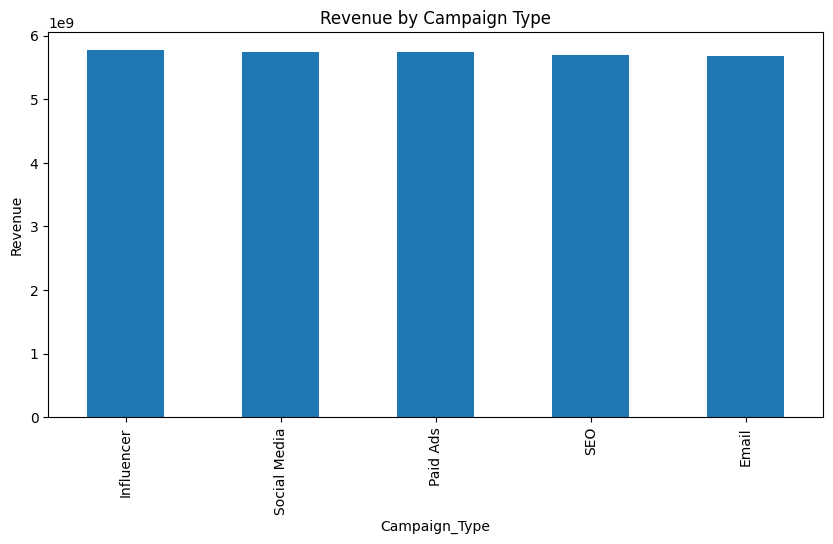

In [14]:
campaign_rev.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Campaign Type")
plt.ylabel("Revenue")
plt.show()

In [15]:
df.groupby(
    "Campaign_Type"
)["ROI"].mean().sort_values(
    ascending=False
)

Campaign_Type
Social Media    2.754784
Paid Ads        2.722275
SEO             2.709630
Influencer      2.699687
Email           2.682663
Name: ROI, dtype: float64

In [16]:
channel = df.groupby(
    "Channel_Used"
).agg({
    "Revenue":"sum",
    "Conversions":"sum",
    "ROI":"mean"
})

channel.sort_values(
    "Revenue",
    ascending=False
)

,Revenue,Conversions,ROI
Channel_Used,,,
Instagram,1639493563,3294211,2.735315
WhatsApp,1615380939,3239706,2.817171
YouTube,1597611646,3242976,2.629917
Email,1587734385,3178048,2.794448
Google,1586013727,3139859,2.577464
...,...,...,...
"WhatsApp, Google, Instagram",62816889,124911,2.510846
"YouTube, WhatsApp, Instagram",61106820,118114,2.448548
"WhatsApp, YouTube, Google",60253318,126046,2.148824


In [18]:
segment = df.groupby(
    "Customer_Segment"
).agg({
    "Revenue":"sum",
    "Conversions":"sum",
    "ROI":"mean"
})

segment.sort_values(
    "Revenue",
    ascending=False
)

,Revenue,Conversions,ROI
Customer_Segment,,,
Working Women,5811927015,11638803,2.771055
College Students,5799502690,11583642,2.699205
Premium Shoppers,5709910379,11445494,2.720461
Tier 2 City Customers,5691846274,11365890,2.699197
Youth,5643177924,11347093,2.679097


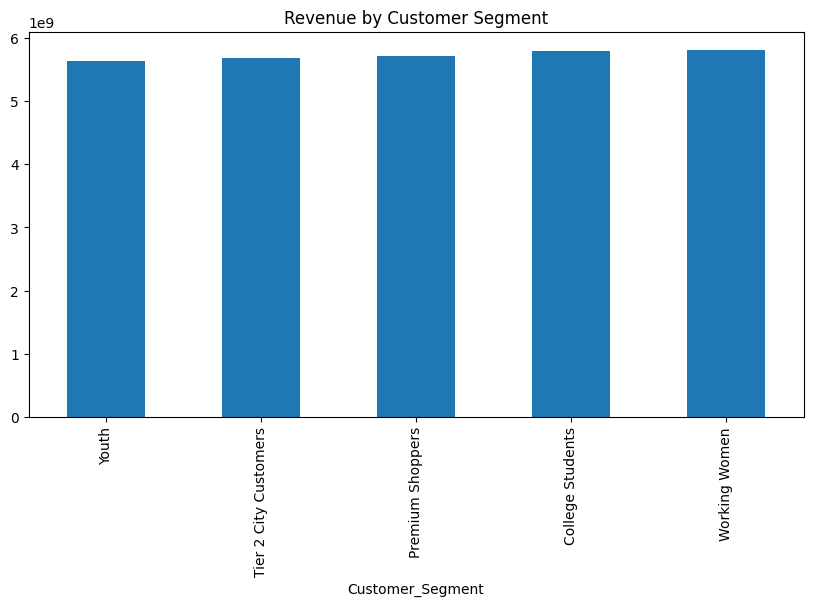

In [19]:
segment["Revenue"].sort_values().plot(
    kind="bar"
)

plt.title("Revenue by Customer Segment")
plt.show()

In [20]:
audience = df.groupby(
    "Target_Audience"
).agg({
    "Revenue":"sum",
    "Conversions":"sum",
    "ROI":"mean"
})

audience.sort_values(
    "Revenue",
    ascending=False
)

,Revenue,Conversions,ROI
Target_Audience,,,
Premium Shoppers,5852284945,11703289,2.801403
College Students,5786247365,11579074,2.736740
Working Women,5743709729,11494222,2.667809
Tier 2 City Customers,5701063841,11419296,2.681424
Youth,5573058402,11185041,2.681190


In [21]:
funnel = pd.DataFrame({
    "Stage":[
        "Impressions",
        "Clicks",
        "Leads",
        "Conversions"
    ],
    "Count":[
        df["Impressions"].sum(),
        df["Clicks"].sum(),
        df["Leads"].sum(),
        df["Conversions"].sum()
    ]
})

funnel

,Stage,Count
0,Impressions,3060407471
1,Clicks,260445757
2,Leads,104291797
3,Conversions,57380922


In [22]:
df["Date"] = pd.to_datetime(
    df["Date"]
)

df["Month"] = df["Date"].dt.to_period("M")

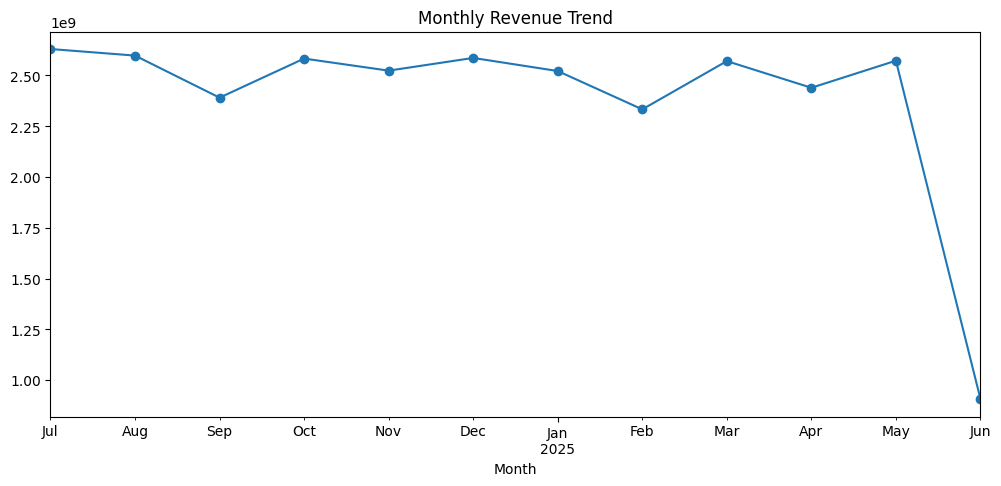

In [23]:
monthly = df.groupby(
    "Month"
)["Revenue"].sum()

monthly.plot(
    marker="o",
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")
plt.show()

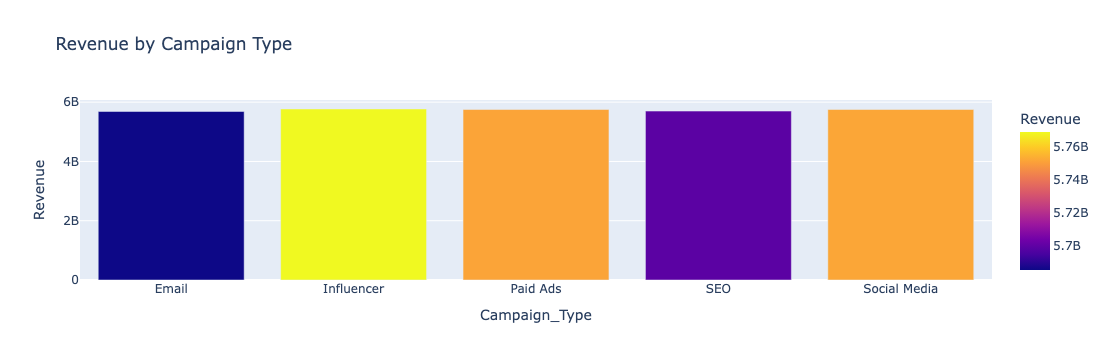

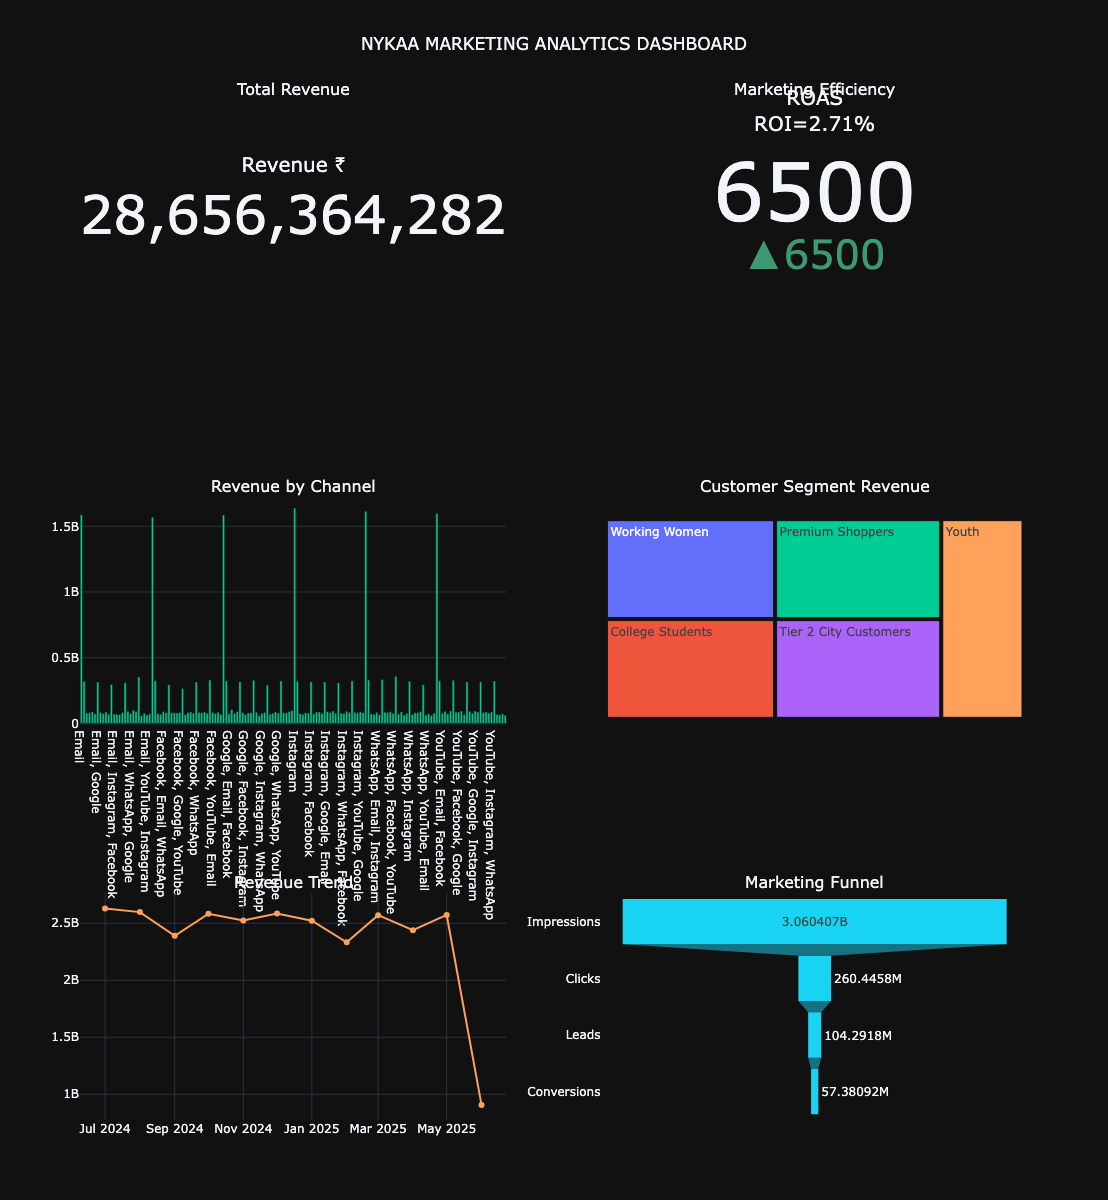

In [28]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

# =========================
# PREPARE DATA
# =========================

df["Date"] = pd.to_datetime(df["Date"])

df["CTR"] = (df["Clicks"] / df["Impressions"]) * 100

df["Conversion_Rate"] = (
    df["Conversions"] / df["Clicks"]
) * 100

df["ROAS"] = (
    df["Revenue"] /
    df["Acquisition_Cost"]
)

df["Month"] = df["Date"].dt.strftime("%Y-%m")

# =========================
# KPI VALUES
# =========================

total_revenue = df["Revenue"].sum()

total_cost = df["Acquisition_Cost"].sum()

total_conversions = df["Conversions"].sum()

avg_roi = df["ROI"].mean()

avg_ctr = df["CTR"].mean()

avg_roas = df["ROAS"].mean()

# =========================
# DASHBOARD
# =========================

fig = make_subplots(

    rows=3,
    cols=2,

    specs=[
        [{"type":"indicator"},{"type":"indicator"}],

        [{"type":"bar"},{"type":"treemap"}],

        [{"type":"scatter"},{"type":"funnel"}]
    ],

    subplot_titles=(

        "Total Revenue",
        "Marketing Efficiency",

        "Revenue by Channel",
        "Customer Segment Revenue",

        "Revenue Trend",
        "Marketing Funnel"
    )
)

# =========================
# KPI CARD 1
# =========================

fig.add_trace(

    go.Indicator(

        mode="number",

        value=total_revenue,

        title={"text":"Revenue ₹"},

        number={
            "valueformat":","
        }

    ),

    row=1,
    col=1
)

# =========================
# KPI CARD 2
# =========================

fig.add_trace(

    go.Indicator(

        mode="number+delta",

        value=avg_roas,

        delta={
            "reference":1
        },

        title={
            "text":f"ROAS<br>ROI={avg_roi:.2f}%"
        }

    ),

    row=1,
    col=2
)

# =========================
# CHANNEL PERFORMANCE
# =========================

channel = df.groupby(
    "Channel_Used"
)["Revenue"].sum().reset_index()

fig.add_trace(

    go.Bar(

        x=channel["Channel_Used"],
        y=channel["Revenue"],
        name="Revenue"

    ),

    row=2,
    col=1
)

# =========================
# TREEMAP
# =========================

segment = df.groupby(
    "Customer_Segment"
)["Revenue"].sum().reset_index()

fig.add_trace(

    go.Treemap(

        labels=segment["Customer_Segment"],

        parents=[""] * len(segment),

        values=segment["Revenue"]

    ),

    row=2,
    col=2
)

# =========================
# MONTHLY TREND
# =========================

monthly = df.groupby(
    "Month"
)["Revenue"].sum().reset_index()

fig.add_trace(

    go.Scatter(

        x=monthly["Month"],

        y=monthly["Revenue"],

        mode="lines+markers",

        name="Revenue"

    ),

    row=3,
    col=1
)

# =========================
# FUNNEL
# =========================

fig.add_trace(

    go.Funnel(

        y=[
            "Impressions",
            "Clicks",
            "Leads",
            "Conversions"
        ],

        x=[
            df["Impressions"].sum(),
            df["Clicks"].sum(),
            df["Leads"].sum(),
            df["Conversions"].sum()
        ]

    ),

    row=3,
    col=2
)

# =========================
# LAYOUT
# =========================

fig.update_layout(

    height=1200,

    width=1600,

    template="plotly_dark",

    title={

        "text":
        "NYKAA MARKETING ANALYTICS DASHBOARD",

        "x":0.5
    },

    showlegend=False

)
# Revenue by Campaign Type
px.bar(
    df.groupby("Campaign_Type")["Revenue"]
      .sum()
      .reset_index(),
    x="Campaign_Type",
    y="Revenue",
    color="Revenue",
    title="Revenue by Campaign Type"
).show()

fig.show()

In [29]:
# Sunburst Chart
px.sunburst(
    df,
    path=[
        "Channel_Used",
        "Campaign_Type",
        "Customer_Segment"
    ],
    values="Revenue"
).show()